# Financial Market Sentiment Prediction

In [1]:
%pip -q install "datasets==3.3.2" "transformers==4.49.0" "accelerate==1.4.0"     "evaluate==0.4.3" "xgboost==2.1.4" "scikit-learn==1.6.1" "joblib==1.4.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires hugg

In [2]:
# Imports and project configuration
import os, re, json, time, random, hashlib, platform, unicodedata, shutil, warnings, gc
from pathlib import Path
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
)
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb
import torch
from datasets import load_dataset, Dataset

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

LABELS = ['negative', 'neutral', 'positive']
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

# T4-friendly transformer configuration
MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

# TF-IDF limit keeps RF/XGBoost practical on free Colab RAM/CPU.
TFIDF_MAX_FEATURES = 15_000

# Set True only for a quick pipeline test. Final dissertation results must use False.
DEBUG_MODE = False
DEBUG_TRAIN_N = 6_000
DEBUG_VAL_N = 1_500
DEBUG_TEST_N = 1_500

# Proposal-aligned classical preprocessing: special-character cleaning + stop-word removal.
# Negation terms are retained because they can reverse sentiment meaning.
CLASSICAL_STOP_WORDS = sorted(set(ENGLISH_STOP_WORDS) - {'no', 'not', 'nor', 'never'})

def preprocess_classical_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[^a-z0-9$%+\-.\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def softmax_np(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def calculate_metrics(y_true, y_pred, y_prob=None):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0,1,2], average='macro', zero_division=0
    )
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0,1,2], average='weighted', zero_division=0
    )
    result = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': p,
        'macro_recall': r,
        'macro_f1': f,
        'weighted_f1': weighted_f1,
    }
    if y_prob is not None:
        try:
            result['roc_auc_ovr_macro'] = roc_auc_score(
                y_true, y_prob, multi_class='ovr', average='macro', labels=[0,1,2]
            )
        except Exception:
            result['roc_auc_ovr_macro'] = np.nan
    else:
        result['roc_auc_ovr_macro'] = np.nan
    return result

print('Python:', platform.python_version())
print('scikit-learn:', sklearn.__version__)
print('xgboost:', xgb.__version__)
print('PyTorch:', torch.__version__)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not enabled')

Python: 3.12.13
scikit-learn: 1.6.1
xgboost: 2.1.4
PyTorch: 2.11.0+cu128
GPU: Tesla T4


In [3]:
import sys
# Mount Google Drive and create persistent folders
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError as e:
    print(f"Error mounting Google Drive: {e}. Please re-run this cell to re-authenticate.", file=sys.stderr)

from pathlib import Path

ROOT = Path('/content/drive/MyDrive/Financial_Market_Sentiment_Project')
W1 = ROOT / 'week1'
W2 = ROOT / 'week2'
W3 = ROOT / 'week3'
W4 = ROOT / 'week4'
FINAL = ROOT / 'final_report_files'

for folder in [W1, W2, W3, W4, FINAL]:
    folder.mkdir(parents=True, exist_ok=True)

for week in [W1, W2, W3, W4]:
    (week / 'figures').mkdir(exist_ok=True)
    (week / 'tables').mkdir(exist_ok=True)

print('Project folder:', ROOT)

Mounted at /content/drive
Project folder: /content/drive/MyDrive/Financial_Market_Sentiment_Project


In [4]:
# Save environment details for reproducibility
import datasets, transformers, accelerate

environment = {
    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'datasets': datasets.__version__,
    'transformers': transformers.__version__,
    'accelerate': accelerate.__version__,
    'xgboost': xgb.__version__,
    'torch': torch.__version__,
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'seed': SEED,
    'debug_mode': DEBUG_MODE,
}
with open(ROOT / 'environment.json', 'w') as f:
    json.dump(environment, f, indent=2)
environment

{'timestamp_utc': '2026-08-09T14:56:47.231222+00:00',
 'python': '3.12.13',
 'numpy': '2.0.2',
 'pandas': '2.2.2',
 'sklearn': '1.6.1',
 'datasets': '3.3.2',
 'transformers': '4.49.0',
 'accelerate': '1.4.0',
 'xgboost': '2.1.4',
 'torch': '2.11.0+cu128',
 'gpu': 'Tesla T4',
 'seed': 42,
 'debug_mode': False}

# Dataset validation, EDA, label harmonisation and leakage control

In [5]:
# 1.1 Load the FinGPT dataset
raw_ds = load_dataset('FinGPT/fingpt-sentiment-train', split='train')
df = raw_ds.to_pandas().reset_index(drop=True)
df['row_id'] = np.arange(len(df))

print('Rows:', len(df))
print('Columns:', df.columns.tolist())
display(df.head(3))

README.md:   0%|          | 0.00/529 [00:00<?, ?B/s]

data/train-00000-of-00001-dabab110260ac9(…):   0%|          | 0.00/6.42M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/76772 [00:00<?, ? examples/s]

Rows: 76772
Columns: ['input', 'output', 'instruction', 'row_id']


,input,output,instruction,row_id
0,"Teollisuuden Voima Oyj , the Finnish utility k...",neutral,What is the sentiment of this news? Please cho...,0
1,Sanofi poaches AstraZeneca scientist as new re...,neutral,What is the sentiment of this news? Please cho...,1
2,Starbucks says the workers violated safety pol...,moderately negative,What is the sentiment of this news? Please cho...,2


In [6]:
# 1.2 Basic data-quality audit
quality_before = pd.DataFrame({
    'metric': [
        'rows', 'missing_input', 'missing_output', 'missing_instruction',
        'empty_input', 'unique_input_exact', 'duplicate_input_exact'
    ],
    'value': [
        len(df),
        df['input'].isna().sum(),
        df['output'].isna().sum(),
        df['instruction'].isna().sum(),
        df['input'].fillna('').astype(str).str.strip().eq('').sum(),
        df['input'].nunique(dropna=True),
        df.duplicated(subset=['input'], keep=False).sum()
    ]
})
display(quality_before)
quality_before.to_csv(W1 / 'tables' / '01_data_quality_before_cleaning.csv', index=False)

print('\nOriginal output labels:')
display(df['output'].astype(str).str.strip().str.lower().value_counts().rename_axis('original_label').reset_index(name='count'))

,metric,value
0,rows,76772
1,missing_input,0
2,missing_output,0
3,missing_instruction,0
4,empty_input,0
5,unique_input_exact,30235
6,duplicate_input_exact,60588



Original output labels:


,original_label,count
0,neutral,29215
1,positive,21588
2,negative,11749
3,moderately positive,6163
4,moderately negative,2972
5,mildly positive,2548
6,mildly negative,2108
7,strong negative,218
8,strong positive,211


In [7]:
# 1.3 Harmonise FinGPT's sentiment intensities into the 3 classes defined in Chapter 1.
def map_sentiment(value):
    s = str(value).strip().lower()
    if 'negative' in s:
        return 'negative'
    if 'positive' in s:
        return 'positive'
    if s == 'neutral' or 'neutral' in s:
        return 'neutral'
    return np.nan

def infer_source_type(instruction):
    s = str(instruction).lower()
    if 'tweet' in s or 'social media' in s:
        return 'social_media'
    if 'news' in s:
        return 'news'
    return 'other'

def normalise_for_duplicate_check(text):
    text = unicodedata.normalize('NFKC', str(text)).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '<url>', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

work = df.copy()
work['text'] = work['input'].fillna('').astype(str).str.strip()
work['sentiment'] = work['output'].apply(map_sentiment)
work['source_type'] = work['instruction'].apply(infer_source_type)
work['norm_text'] = work['text'].apply(normalise_for_duplicate_check)
work['word_count'] = work['text'].str.split().str.len()

unmapped = work.loc[work['sentiment'].isna(), 'output'].value_counts(dropna=False)
print('Unmapped rows:', int(work['sentiment'].isna().sum()))
if len(unmapped):
    display(unmapped)

mapping_table = (
    work.groupby(['output', 'sentiment'], dropna=False).size()
        .reset_index(name='count').sort_values('count', ascending=False)
)
display(mapping_table)
mapping_table.to_csv(W1 / 'tables' / '02_label_harmonisation.csv', index=False)

Unmapped rows: 0


,output,sentiment,count
5,neutral,neutral,29215
6,positive,positive,21588
4,negative,negative,11749
3,moderately positive,positive,6163
2,moderately negative,negative,2972
1,mildly positive,positive,2548
0,mildly negative,negative,2108
7,strong negative,negative,218
8,strong positive,positive,211


In [8]:
# 1.4 Remove unusable rows, conflicting duplicate labels and duplicate texts.
clean = work[(work['text'] != '') & work['sentiment'].notna()].copy()

label_counts_per_text = clean.groupby('norm_text')['sentiment'].nunique()
conflicting_norm_texts = set(label_counts_per_text[label_counts_per_text > 1].index)

conflicting_rows = clean[clean['norm_text'].isin(conflicting_norm_texts)].copy()
conflicting_rows[['row_id', 'text', 'output', 'sentiment', 'source_type']].to_csv(
    W1 / 'tables' / '03_conflicting_duplicate_rows.csv', index=False
)

rows_before = len(clean)
clean = clean[~clean['norm_text'].isin(conflicting_norm_texts)].copy()
removed_conflicts = rows_before - len(clean)

rows_before_dedup = len(clean)
clean = clean.drop_duplicates(subset=['norm_text'], keep='first').reset_index(drop=True)
removed_duplicates = rows_before_dedup - len(clean)

clean['label_id'] = clean['sentiment'].map(LABEL2ID).astype(int)

quality_after = pd.DataFrame({
    'metric': ['original_rows', 'removed_conflicting_rows', 'removed_duplicate_rows', 'final_clean_rows'],
    'value': [len(df), removed_conflicts, removed_duplicates, len(clean)]
})
display(quality_after)
quality_after.to_csv(W1 / 'tables' / '04_data_quality_after_cleaning.csv', index=False)

,metric,value
0,original_rows,76772
1,removed_conflicting_rows,4
2,removed_duplicate_rows,46628
3,final_clean_rows,30140


,sentiment,count,percentage
0,negative,7453,24.727936
1,neutral,10290,34.140677
2,positive,12397,41.131387


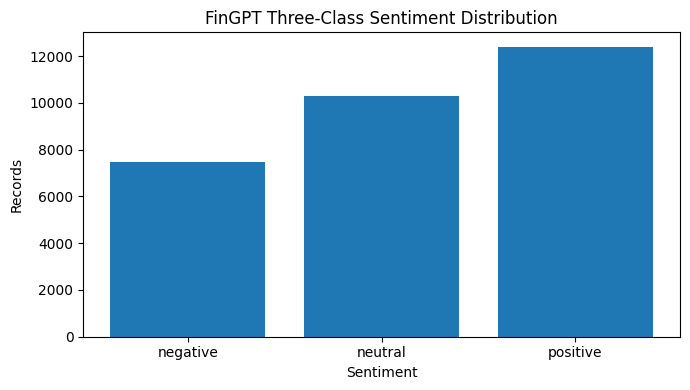

,source_type,count,percentage
0,news,20166,66.907764
1,social_media,9974,33.092236


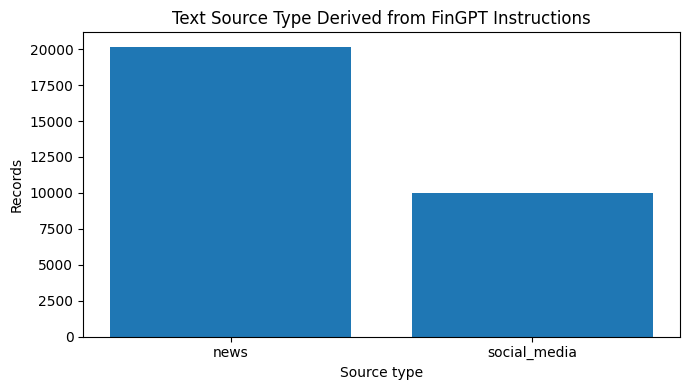

,word_count
count,30140.000000
mean,21.517021
std,13.569119
min,1.000000
50%,18.000000
75%,28.000000
90%,40.000000
95%,48.000000
99%,65.000000
max,303.000000


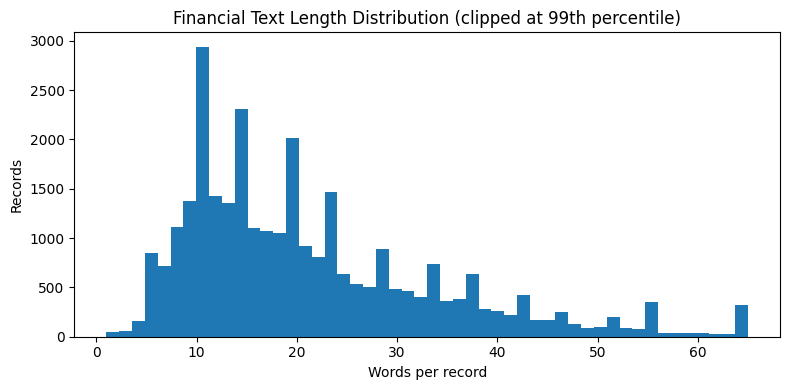

In [9]:
# 1.5 EDA — class distribution, source type and text length.
class_dist = clean['sentiment'].value_counts().reindex(LABELS).rename_axis('sentiment').reset_index(name='count')
class_dist['percentage'] = 100 * class_dist['count'] / class_dist['count'].sum()
display(class_dist)
class_dist.to_csv(W1 / 'tables' / '05_class_distribution.csv', index=False)

plt.figure(figsize=(7,4))
plt.bar(class_dist['sentiment'], class_dist['count'])
plt.title('FinGPT Three-Class Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Records')
plt.tight_layout()
plt.savefig(W1 / 'figures' / '01_class_distribution.png', dpi=200)
plt.show()

source_dist = clean['source_type'].value_counts().rename_axis('source_type').reset_index(name='count')
source_dist['percentage'] = 100 * source_dist['count'] / source_dist['count'].sum()
display(source_dist)
source_dist.to_csv(W1 / 'tables' / '06_source_distribution.csv', index=False)

plt.figure(figsize=(7,4))
plt.bar(source_dist['source_type'], source_dist['count'])
plt.title('Text Source Type Derived from FinGPT Instructions')
plt.xlabel('Source type')
plt.ylabel('Records')
plt.tight_layout()
plt.savefig(W1 / 'figures' / '02_source_distribution.png', dpi=200)
plt.show()

length_summary = clean['word_count'].describe(percentiles=[.5,.75,.9,.95,.99]).to_frame('word_count')
display(length_summary)
length_summary.to_csv(W1 / 'tables' / '07_text_length_summary.csv')

plt.figure(figsize=(8,4))
plt.hist(clean['word_count'].clip(upper=clean['word_count'].quantile(.99)), bins=50)
plt.title('Financial Text Length Distribution (clipped at 99th percentile)')
plt.xlabel('Words per record')
plt.ylabel('Records')
plt.tight_layout()
plt.savefig(W1 / 'figures' / '03_text_length_distribution.png', dpi=200)
plt.show()

In [10]:
# 1.6 Create the locked 70/15/15 stratified split.
train_df, temp_df = train_test_split(
    clean, test_size=0.30, random_state=SEED, stratify=clean['label_id']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label_id']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Optional debug sampling preserves labels. NEVER use DEBUG_MODE results in the dissertation.
def stratified_debug_sample(data, n):
    if len(data) <= n:
        return data.copy().reset_index(drop=True)
    sampled, _ = train_test_split(data, train_size=n, random_state=SEED, stratify=data['label_id'])
    return sampled.reset_index(drop=True)

if DEBUG_MODE:
    train_df = stratified_debug_sample(train_df, DEBUG_TRAIN_N)
    val_df = stratified_debug_sample(val_df, DEBUG_VAL_N)
    test_df = stratified_debug_sample(test_df, DEBUG_TEST_N)
    print('WARNING: DEBUG_MODE is ON. Do not report these results.')

# Explicit leakage check after splitting.
train_texts = set(train_df['norm_text'])
val_texts = set(val_df['norm_text'])
test_texts = set(test_df['norm_text'])
leakage = {
    'train_validation_overlap': len(train_texts & val_texts),
    'train_test_overlap': len(train_texts & test_texts),
    'validation_test_overlap': len(val_texts & test_texts),
}
print(leakage)
assert sum(leakage.values()) == 0, 'Leakage detected: stop and inspect the split.'

split_summary = []
for name, part in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    row = {'split': name, 'rows': len(part)}
    for label in LABELS:
        row[label] = int((part['sentiment'] == label).sum())
    split_summary.append(row)
split_summary = pd.DataFrame(split_summary)
display(split_summary)
split_summary.to_csv(W1 / 'tables' / '08_split_summary.csv', index=False)

# Save only required modelling columns. Test remains untouched until Week 4.
keep_cols = ['row_id', 'text', 'sentiment', 'label_id', 'source_type', 'norm_text', 'word_count']
train_df[keep_cols].to_parquet(W1 / 'train_locked.parquet', index=False)
val_df[keep_cols].to_parquet(W1 / 'validation_locked.parquet', index=False)
test_df[keep_cols].to_parquet(W1 / 'test_LOCKED_DO_NOT_EVALUATE_BEFORE_WEEK4.parquet', index=False)

with open(W1 / 'split_metadata.json', 'w') as f:
    json.dump({'seed': SEED, 'ratios': {'train': .70, 'validation': .15, 'test': .15}, **leakage}, f, indent=2)

{'train_validation_overlap': 0, 'train_test_overlap': 0, 'validation_test_overlap': 0}


,split,rows,negative,neutral,positive
0,train,21098,5217,7203,8678
1,validation,4521,1118,1543,1860
2,test,4521,1118,1544,1859


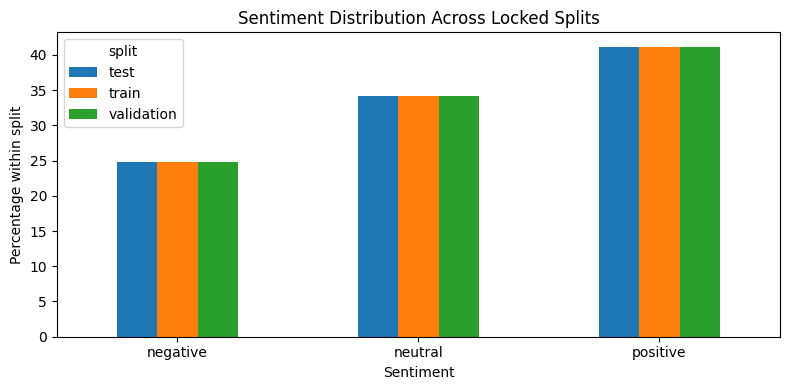

WEEK 1 COMPLETE — clean data and leakage-controlled splits saved to Google Drive.


In [11]:
# 1.7 Visual confirmation of split class balance.
split_plot = pd.concat([
    train_df.assign(split='train'), val_df.assign(split='validation'), test_df.assign(split='test')
]).groupby(['split','sentiment']).size().reset_index(name='count')
split_plot['percentage'] = split_plot.groupby('split')['count'].transform(lambda x: 100*x/x.sum())

pivot = split_plot.pivot(index='sentiment', columns='split', values='percentage').reindex(LABELS)
pivot.plot(kind='bar', figsize=(8,4))
plt.title('Sentiment Distribution Across Locked Splits')
plt.ylabel('Percentage within split')
plt.xlabel('Sentiment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(W1 / 'figures' / '04_split_class_balance.png', dpi=200)
plt.show()

print('WEEK 1 COMPLETE — clean data and leakage-controlled splits saved to Google Drive.')

# Traditional machine-learning models


In [12]:
# 2.1 Reload locked Week 1 data so Week 2 can run in a new Colab session.
train_df = pd.read_parquet(W1 / 'train_locked.parquet')
val_df = pd.read_parquet(W1 / 'validation_locked.parquet')

# Shared TF-IDF representation for a controlled ML comparison.
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.98,
    max_features=TFIDF_MAX_FEATURES,
    sublinear_tf=True,
    strip_accents='unicode',
    stop_words=CLASSICAL_STOP_WORDS
)

t0 = time.perf_counter()
train_classical_text = train_df['text'].map(preprocess_classical_text)
val_classical_text = val_df['text'].map(preprocess_classical_text)
X_train = tfidf.fit_transform(train_classical_text)
X_val = tfidf.transform(val_classical_text)
tfidf_seconds = time.perf_counter() - t0

y_train = train_df['label_id'].to_numpy()
y_val = val_df['label_id'].to_numpy()

joblib.dump(tfidf, W2 / 'tfidf_vectorizer.joblib')
print('Train TF-IDF shape:', X_train.shape)
print('TF-IDF fit/transform seconds:', round(tfidf_seconds, 2))

Train TF-IDF shape: (21098, 15000)
TF-IDF fit/transform seconds: 1.67


In [13]:
# 2.2 Classical-model training/evaluation helper.
def evaluate_sklearn_model(name, model, X_fit, y_fit, X_eval, y_eval, sample_weight=None):
    t0 = time.perf_counter()
    if sample_weight is None:
        model.fit(X_fit, y_fit)
    else:
        model.fit(X_fit, y_fit, sample_weight=sample_weight)
    train_seconds = time.perf_counter() - t0

    t0 = time.perf_counter()
    pred = model.predict(X_eval)
    prob = model.predict_proba(X_eval) if hasattr(model, 'predict_proba') else None
    prediction_seconds = time.perf_counter() - t0

    metrics = calculate_metrics(y_eval, pred, prob)
    metrics.update({'model': name, 'training_seconds': train_seconds, 'prediction_seconds': prediction_seconds})
    return metrics, pred, prob

In [14]:
# 2.3 Train the proposal's traditional ML models.
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=700, class_weight='balanced', solver='lbfgs', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=120, max_depth=30, min_samples_leaf=2,
        class_weight='balanced_subsample', n_jobs=-1, random_state=SEED
    ),
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softprob', num_class=3, n_estimators=200,
        max_depth=4, learning_rate=0.08, subsample=0.90,
        colsample_bytree=0.80, min_child_weight=2,
        reg_lambda=1.0, tree_method='hist', eval_metric='mlogloss',
        n_jobs=-1, random_state=SEED
    )
}


model_config = pd.DataFrame([
    {'model':'Logistic Regression','representation':'TF-IDF 1-2 grams','key_settings':'C=1.0; balanced class weights'},
    {'model':'Random Forest','representation':'TF-IDF 1-2 grams','key_settings':'120 trees; max_depth=30; balanced_subsample'},
    {'model':'XGBoost','representation':'TF-IDF 1-2 grams','key_settings':'200 trees; max_depth=4; balanced sample weights'},
])
model_config.to_csv(W2 / 'tables' / '00_ml_model_configuration.csv', index=False)

ml_val_rows = []
ml_val_predictions = {}
ml_val_probabilities = {}

balanced_weights = compute_sample_weight(class_weight='balanced', y=y_train)

for name, model in models.items():
    print(f'\nTraining {name}...')
    weights = balanced_weights if name == 'XGBoost' else None
    metrics, pred, prob = evaluate_sklearn_model(name, model, X_train, y_train, X_val, y_val, weights)
    ml_val_rows.append(metrics)
    ml_val_predictions[name] = pred
    ml_val_probabilities[name] = prob
    joblib.dump(model, W2 / f"{name.lower().replace(' ', '_')}.joblib")
    print({k: round(v,4) if isinstance(v,(float,np.floating)) else v for k,v in metrics.items()})

ml_validation = pd.DataFrame(ml_val_rows).sort_values('macro_f1', ascending=False)
display(ml_validation)
ml_validation.to_csv(W2 / 'tables' / '01_ml_validation_metrics.csv', index=False)

with open(W2 / 'timing.json', 'w') as f:
    json.dump({'tfidf_seconds': tfidf_seconds, **{r['model']: r['training_seconds'] for r in ml_val_rows}}, f, indent=2)


Training Logistic Regression...
{'accuracy': 0.6976, 'macro_precision': 0.6907, 'macro_recall': 0.6951, 'macro_f1': 0.6921, 'weighted_f1': 0.6976, 'roc_auc_ovr_macro': np.float64(0.8636), 'model': 'Logistic Regression', 'training_seconds': 6.1909, 'prediction_seconds': 0.0073}

Training Random Forest...
{'accuracy': 0.6184, 'macro_precision': 0.6311, 'macro_recall': 0.6139, 'macro_f1': 0.6041, 'weighted_f1': 0.6092, 'roc_auc_ovr_macro': np.float64(0.7969), 'model': 'Random Forest', 'training_seconds': 2.8932, 'prediction_seconds': 0.1563}

Training XGBoost...
{'accuracy': 0.6238, 'macro_precision': 0.6312, 'macro_recall': 0.6196, 'macro_f1': 0.6107, 'weighted_f1': 0.6157, 'roc_auc_ovr_macro': np.float64(0.801), 'model': 'XGBoost', 'training_seconds': 56.4399, 'prediction_seconds': 0.1995}


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_macro,model,training_seconds,prediction_seconds
0,0.697633,0.690661,0.695108,0.692089,0.697588,0.863649,Logistic Regression,6.190885,0.007337
2,0.623756,0.631151,0.619608,0.610736,0.615718,0.800980,XGBoost,56.439918,0.199500
1,0.618447,0.631082,0.613866,0.604149,0.609243,0.796938,Random Forest,2.893231,0.156273


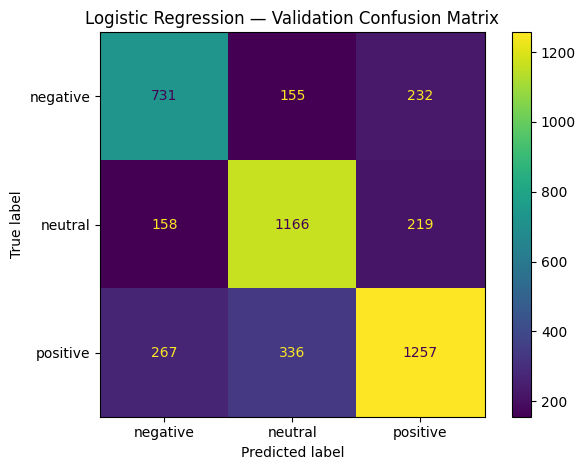

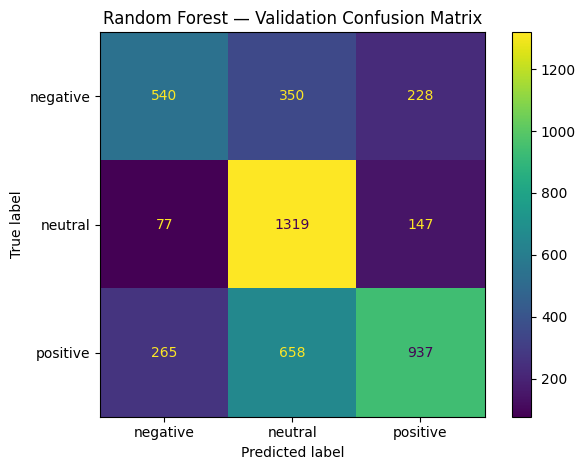

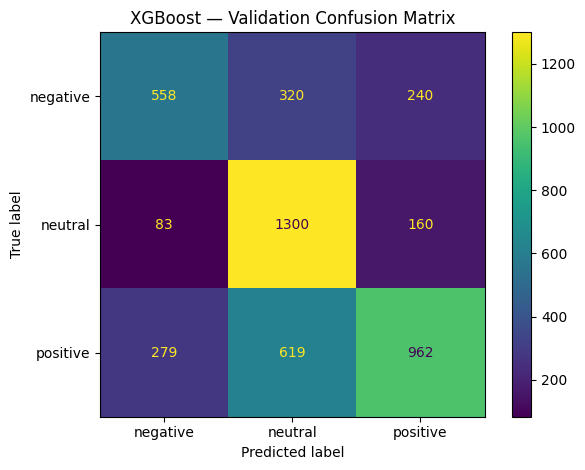

Best traditional model by validation Macro F1: Logistic Regression
WEEK 2 COMPLETE — test set has not been used.


In [15]:
# 2.4 Validation confusion matrices and per-class reports.
for name, pred in ml_val_predictions.items():
    cm = confusion_matrix(y_val, pred, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    disp.plot(values_format='d')
    plt.title(f'{name} — Validation Confusion Matrix')
    plt.tight_layout()
    plt.savefig(W2 / 'figures' / f"{name.lower().replace(' ', '_')}_validation_confusion_matrix.png", dpi=200)
    plt.show()

    report = pd.DataFrame(classification_report(
        y_val, pred, labels=[0,1,2], target_names=LABELS, output_dict=True, zero_division=0
    )).T
    report.to_csv(W2 / 'tables' / f"{name.lower().replace(' ', '_')}_validation_classification_report.csv")

best_ml_name = ml_validation.iloc[0]['model']
print('Best traditional model by validation Macro F1:', best_ml_name)
print('WEEK 2 COMPLETE — test set has not been used.')

#  BERT and FinBERT fine-tuning

In [16]:
# 3.1 Verify GPU and reload locked train/validation data.
if not torch.cuda.is_available():
    raise RuntimeError('Enable a T4 GPU: Runtime -> Change runtime type -> T4 GPU, then rerun from this cell.')

print('GPU:', torch.cuda.get_device_name(0))
train_df = pd.read_parquet(W1 / 'train_locked.parquet')
val_df = pd.read_parquet(W1 / 'validation_locked.parquet')
y_train = train_df['label_id'].to_numpy()
y_val = val_df['label_id'].to_numpy()

from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer,
    EarlyStoppingCallback, set_seed
)
from transformers.trainer_utils import get_last_checkpoint

set_seed(SEED)
transformer_class_weights = compute_class_weight(
    class_weight='balanced', classes=np.array([0,1,2]), y=y_train
)
transformer_class_weights = torch.tensor(transformer_class_weights, dtype=torch.float32)
print('Transformer class weights:', transformer_class_weights.tolist())

GPU: Tesla T4
Transformer class weights: [1.3480288982391357, 0.9763524532318115, 0.8104017972946167]


In [17]:
# 3.2 Transformer training function — restart-safe for Colab.
def hf_dataset_from_frame(frame, tokenizer):
    ds = Dataset.from_pandas(frame[['text','label_id']], preserve_index=False)
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)
    ds = ds.map(tokenize, batched=True, remove_columns=['text'])
    ds = ds.rename_column('label_id', 'labels')
    return ds

def transformer_compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred = np.argmax(logits, axis=1)
    return calculate_metrics(labels, pred, softmax_np(logits))

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        weights = self.class_weights.to(logits.device)
        loss = torch.nn.functional.cross_entropy(logits, labels, weight=weights)
        return (loss, outputs) if return_outputs else loss


def train_transformer(model_name, model_tag):
    run_dir = W3 / f'{model_tag}_checkpoints'
    best_dir = W3 / f'{model_tag}_best_model'
    metrics_file = W3 / 'tables' / f'{model_tag}_validation_metrics.csv'

    # If this model already completed successfully, reuse it instead of retraining.
    if best_dir.exists() and metrics_file.exists():
        print(f'{model_tag} already completed; loading saved validation metrics.')
        return pd.read_csv(metrics_file).iloc[0].to_dict()

    run_dir.mkdir(exist_ok=True)
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    train_ds = hf_dataset_from_frame(train_df, tokenizer)
    val_ds = hf_dataset_from_frame(val_df, tokenizer)
    collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True
    )

    args = TrainingArguments(
        output_dir=str(run_dir),
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_strategy='steps',
        logging_steps=200,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=0.10,
        fp16=True,
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        save_total_limit=1,
        report_to='none',
        seed=SEED,
        data_seed=SEED,
        dataloader_num_workers=2,
        group_by_length=True,
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=collator,
        compute_metrics=transformer_compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
        class_weights=transformer_class_weights
    )

    last_checkpoint = get_last_checkpoint(str(run_dir)) if run_dir.exists() else None
    if last_checkpoint:
        print('Resuming from:', last_checkpoint)

    t0 = time.perf_counter()
    trainer.train(resume_from_checkpoint=last_checkpoint if last_checkpoint else None)
    training_seconds = time.perf_counter() - t0

    # Validation predictions from the selected best checkpoint.
    t0 = time.perf_counter()
    pred_output = trainer.predict(val_ds)
    validation_prediction_seconds = time.perf_counter() - t0
    val_logits = pred_output.predictions
    val_prob = softmax_np(val_logits)
    val_pred = val_prob.argmax(axis=1)
    val_metrics = calculate_metrics(y_val, val_pred, val_prob)
    val_metrics.update({
        'model': model_tag,
        'base_model': model_name,
        'training_seconds': training_seconds,
        'prediction_seconds': validation_prediction_seconds,
        'best_checkpoint': trainer.state.best_model_checkpoint,
    })

    # Save compact best model and tokenizer; remove temporary checkpoints after success.
    trainer.save_model(str(best_dir))
    tokenizer.save_pretrained(str(best_dir))

    pd.DataFrame(trainer.state.log_history).to_csv(W3 / 'tables' / f'{model_tag}_training_history.csv', index=False)
    pd.DataFrame([val_metrics]).to_csv(W3 / 'tables' / f'{model_tag}_validation_metrics.csv', index=False)

    val_out = pd.DataFrame({
        'row_id': val_df['row_id'],
        'true_label': y_val,
        'prediction': val_pred,
        'prob_negative': val_prob[:,0],
        'prob_neutral': val_prob[:,1],
        'prob_positive': val_prob[:,2],
    })
    val_out.to_csv(W3 / 'tables' / f'{model_tag}_validation_predictions.csv', index=False)

    cm = confusion_matrix(y_val, val_pred, labels=[0,1,2])
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(values_format='d')
    plt.title(f'{model_tag} — Validation Confusion Matrix')
    plt.tight_layout()
    plt.savefig(W3 / 'figures' / f'{model_tag}_validation_confusion_matrix.png', dpi=200)
    plt.show()

    hist = pd.DataFrame(trainer.state.log_history)
    if 'loss' in hist.columns:
        tmp = hist.dropna(subset=['loss'])
        if len(tmp):
            plt.figure(figsize=(7,4))
            plt.plot(tmp['step'], tmp['loss'])
            plt.title(f'{model_tag} Training Loss')
            plt.xlabel('Training step')
            plt.ylabel('Loss')
            plt.tight_layout()
            plt.savefig(W3 / 'figures' / f'{model_tag}_training_loss.png', dpi=200)
            plt.show()

    if 'eval_macro_f1' in hist.columns:
        tmp = hist.dropna(subset=['eval_macro_f1'])
        if len(tmp):
            plt.figure(figsize=(7,4))
            plt.plot(range(1, len(tmp)+1), tmp['eval_macro_f1'], marker='o')
            plt.title(f'{model_tag} Validation Macro F1')
            plt.xlabel('Evaluation epoch')
            plt.ylabel('Macro F1')
            plt.xticks(range(1, len(tmp)+1))
            plt.tight_layout()
            plt.savefig(W3 / 'figures' / f'{model_tag}_validation_macro_f1.png', dpi=200)
            plt.show()

    # Remove temporary run checkpoints; the selected model is already saved.
    if run_dir.exists():
        shutil.rmtree(run_dir, ignore_errors=True)

    del trainer, model, train_ds, val_ds
    gc.collect()
    torch.cuda.empty_cache()
    return val_metrics

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/21098 [00:00<?, ? examples/s]

Map:   0%|          | 0/4521 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Roc Auc Ovr Macro
1,0.549000,0.503662,0.795178,0.792272,0.804983,0.795818,0.795080,0.931192
2,0.394200,0.495138,0.814422,0.811786,0.819172,0.814431,0.814537,0.942014
3,0.227300,0.603190,0.815970,0.814426,0.814984,0.814415,0.815778,0.939285


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


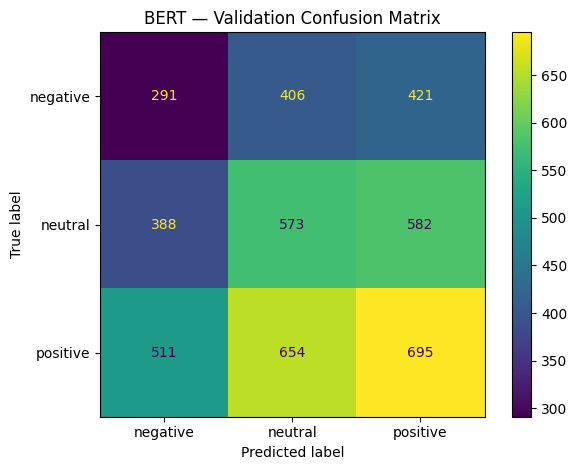

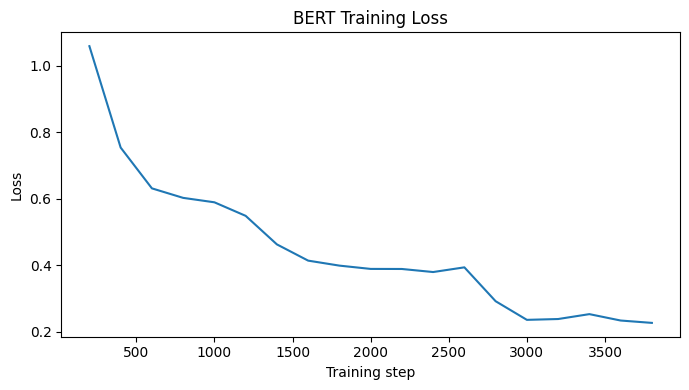

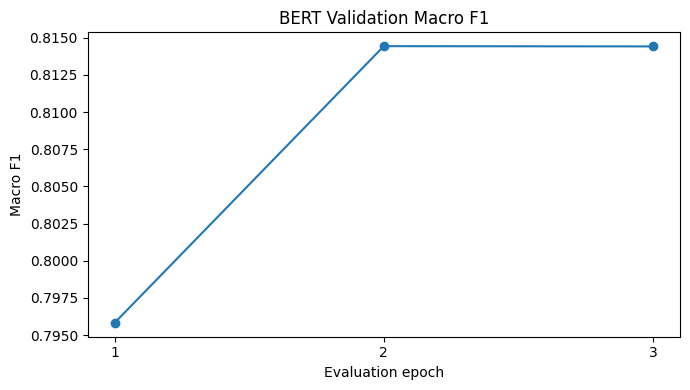

{'accuracy': 0.3448352134483521,
 'macro_precision': 0.33491027207389346,
 'macro_recall': 0.3350988811978574,
 'macro_f1': 0.33455550906469084,
 'weighted_f1': 0.3462350778548642,
 'roc_auc_ovr_macro': np.float64(0.4961209076777764),
 'model': 'BERT',
 'base_model': 'google-bert/bert-base-uncased',
 'training_seconds': 464.31538286499995,
 'prediction_seconds': 6.50387410899998,
 'best_checkpoint': '/content/drive/MyDrive/Financial_Market_Sentiment_Project/week3/BERT_checkpoints/checkpoint-2638'}

In [18]:
# 3.3 Fine-tune general-purpose BERT.
bert_val_metrics = train_transformer(
    model_name='google-bert/bert-base-uncased',
    model_tag='BERT'
)
bert_val_metrics

config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/21098 [00:00<?, ? examples/s]

Map:   0%|          | 0/4521 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at yiyanghkust/finbert-pretrain and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Roc Auc Ovr Macro
1,0.540000,0.525370,0.782349,0.777609,0.788474,0.781110,0.782594,0.926093
2,0.365000,0.579574,0.788542,0.785166,0.798125,0.788247,0.788590,0.930242
3,0.208600,0.715852,0.799381,0.797106,0.798150,0.796898,0.799242,0.926762


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


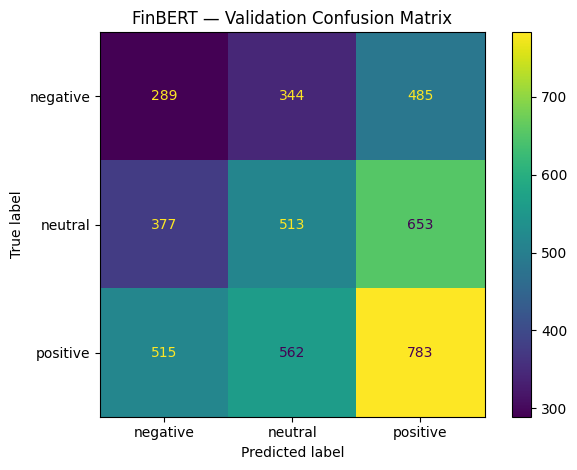

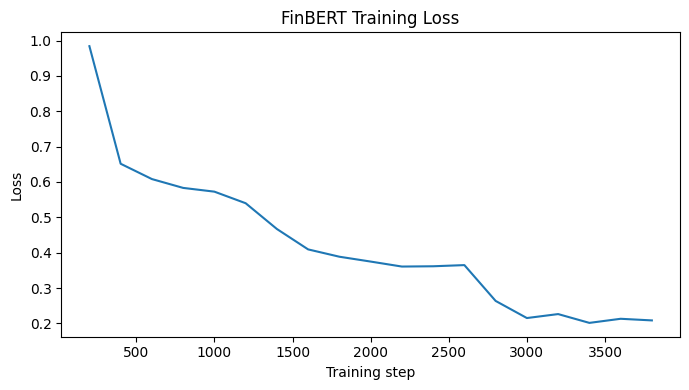

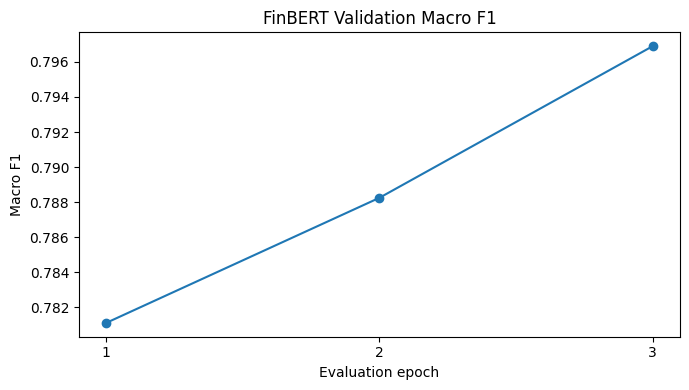

{'accuracy': 0.35058615350586153,
 'macro_precision': 0.33794342721295206,
 'macro_recall': 0.33731142479522863,
 'macro_f1': 0.3373257926505639,
 'weighted_f1': 0.35079056117913376,
 'roc_auc_ovr_macro': np.float64(0.5046543080862286),
 'model': 'FinBERT',
 'base_model': 'yiyanghkust/finbert-pretrain',
 'training_seconds': 471.88534501900017,
 'prediction_seconds': 4.440650089000201,
 'best_checkpoint': '/content/drive/MyDrive/Financial_Market_Sentiment_Project/week3/FinBERT_checkpoints/checkpoint-3957'}

In [19]:
# 3.4 Fine-tune finance-pretrained FinBERT.
finbert_val_metrics = train_transformer(
    model_name='yiyanghkust/finbert-pretrain',
    model_tag='FinBERT'
)
finbert_val_metrics

In [20]:
# 3.5 Validation-only cross-model table. This is model-development evidence, not final test performance.
ml_validation = pd.read_csv(W2 / 'tables' / '01_ml_validation_metrics.csv')
transformer_validation = pd.DataFrame([bert_val_metrics, finbert_val_metrics])

validation_compare = pd.concat([
    ml_validation[['model','accuracy','macro_precision','macro_recall','macro_f1','weighted_f1','roc_auc_ovr_macro','training_seconds','prediction_seconds']],
    transformer_validation[['model','accuracy','macro_precision','macro_recall','macro_f1','weighted_f1','roc_auc_ovr_macro','training_seconds','prediction_seconds']]
], ignore_index=True).sort_values('macro_f1', ascending=False)

display(validation_compare)
validation_compare.to_csv(W3 / 'tables' / '03_all_models_validation_comparison.csv', index=False)
print('WEEK 3 COMPLETE — test set is still locked.')

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_macro,training_seconds,prediction_seconds
0,Logistic Regression,0.697633,0.690661,0.695108,0.692089,0.697588,0.863649,6.190885,0.007337
1,XGBoost,0.623756,0.631151,0.619608,0.610736,0.615718,0.800980,56.439918,0.199500
2,Random Forest,0.618447,0.631082,0.613866,0.604149,0.609243,0.796938,2.893231,0.156273
4,FinBERT,0.350586,0.337943,0.337311,0.337326,0.350791,0.504654,471.885345,4.440650
3,BERT,0.344835,0.334910,0.335099,0.334556,0.346235,0.496121,464.315383,6.503874


WEEK 3 COMPLETE — test set is still locked.


# Final locked test evaluation and research comparison

In [21]:
# 4.1 Load the locked test set and required artefacts.
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer
test_df = pd.read_parquet(W1 / 'test_LOCKED_DO_NOT_EVALUATE_BEFORE_WEEK4.parquet')
y_test = test_df['label_id'].to_numpy()

tfidf = joblib.load(W2 / 'tfidf_vectorizer.joblib')
test_classical_text = test_df['text'].map(preprocess_classical_text)
X_test = tfidf.transform(test_classical_text)

TEST_DONE_FLAG = W4 / 'FINAL_TEST_EVALUATION_COMPLETE.flag'
ALLOW_TEST_RERUN = False  # Only change if you intentionally need to regenerate the final test results.

if TEST_DONE_FLAG.exists() and not ALLOW_TEST_RERUN:
    print('Final test evaluation has already been completed. Existing results will be loaded.')
else:
    print('Test set unlocked for FINAL evaluation only.')

Test set unlocked for FINAL evaluation only.


In [22]:
# 4.2 Helper for transformer test prediction.
def transformer_test_predict(best_model_dir):
    tokenizer = AutoTokenizer.from_pretrained(str(best_model_dir), use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(best_model_dir))
    model.eval()
    model.to('cuda')

    ds = Dataset.from_pandas(test_df[['text','label_id']], preserve_index=False)
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)
    ds = ds.map(tokenize, batched=True, remove_columns=['text'])
    ds = ds.rename_column('label_id', 'labels')

    collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)
    args = TrainingArguments(
        output_dir='/content/test_predict_tmp',
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=True,
        report_to='none',
        dataloader_num_workers=2
    )
    trainer = Trainer(model=model, args=args, processing_class=tokenizer, data_collator=collator)

    t0 = time.perf_counter()
    output = trainer.predict(ds)
    seconds = time.perf_counter() - t0
    prob = softmax_np(output.predictions)
    pred = prob.argmax(axis=1)

    del trainer, model, ds
    gc.collect()
    torch.cuda.empty_cache()
    return pred, prob, seconds

def path_size_mb(path):
    path = Path(path)
    if path.is_file():
        return path.stat().st_size / (1024**2)
    return sum(p.stat().st_size for p in path.rglob('*') if p.is_file()) / (1024**2)

In [23]:
# 4.3 Run the final test evaluation ONCE.
if (not TEST_DONE_FLAG.exists()) or ALLOW_TEST_RERUN:
    final_rows = []
    all_predictions = pd.DataFrame({
        'row_id': test_df['row_id'],
        'source_type': test_df['source_type'],
        'true_label_id': y_test,
        'true_sentiment': test_df['sentiment'],
    })

    # Load Week 2 training times.
    with open(W2 / 'timing.json') as f:
        timing = json.load(f)

    ml_paths = {
        'Logistic Regression': W2 / 'logistic_regression.joblib',
        'Random Forest': W2 / 'random_forest.joblib',
        'XGBoost': W2 / 'xgboost.joblib',
    }

    for name, path in ml_paths.items():
        model = joblib.load(path)
        t0 = time.perf_counter()
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)
        pred_seconds = time.perf_counter() - t0
        metrics = calculate_metrics(y_test, pred, prob)
        metrics.update({
            'model': name,
            'family': 'Traditional ML',
            'training_seconds': timing.get(name, np.nan),
            'prediction_seconds': pred_seconds,
            'model_size_mb': path_size_mb(path),
        })
        final_rows.append(metrics)
        all_predictions[f'{name}_prediction'] = pred
        all_predictions[f'{name}_confidence'] = prob.max(axis=1)
        for i, label in enumerate(LABELS):
            all_predictions[f'{name}_prob_{label}'] = prob[:,i]

    # Transformer training times from Week 3 validation files.
    for name in ['BERT', 'FinBERT']:
        val_metric = pd.read_csv(W3 / 'tables' / f'{name}_validation_metrics.csv').iloc[0]
        best_dir = W3 / f'{name}_best_model'
        pred, prob, pred_seconds = transformer_test_predict(best_dir)
        metrics = calculate_metrics(y_test, pred, prob)
        metrics.update({
            'model': name,
            'family': 'Transformer',
            'training_seconds': float(val_metric['training_seconds']),
            'prediction_seconds': pred_seconds,
            'model_size_mb': path_size_mb(best_dir),
        })
        final_rows.append(metrics)
        all_predictions[f'{name}_prediction'] = pred
        all_predictions[f'{name}_confidence'] = prob.max(axis=1)
        for i, label in enumerate(LABELS):
            all_predictions[f'{name}_prob_{label}'] = prob[:,i]

    final_results = pd.DataFrame(final_rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)
    final_results.to_csv(W4 / 'tables' / '01_FINAL_test_model_comparison.csv', index=False)
    all_predictions.to_csv(W4 / 'tables' / '02_FINAL_test_predictions.csv', index=False)

    # Write the flag only after all five models finish successfully.
    TEST_DONE_FLAG.write_text(datetime.now(timezone.utc).isoformat())
else:
    final_results = pd.read_csv(W4 / 'tables' / '01_FINAL_test_model_comparison.csv')
    all_predictions = pd.read_csv(W4 / 'tables' / '02_FINAL_test_predictions.csv')

display(final_results)

Map:   0%|          | 0/4521 [00:00<?, ? examples/s]

Map:   0%|          | 0/4521 [00:00<?, ? examples/s]

,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc_ovr_macro,model,family,training_seconds,prediction_seconds,model_size_mb
0,0.820836,0.817667,0.825393,0.820892,0.820888,0.944497,BERT,Transformer,464.315383,6.538694,418.579827
1,0.810219,0.808334,0.811044,0.808994,0.810142,0.933732,FinBERT,Transformer,471.885345,5.925463,419.603692
2,0.711789,0.705246,0.710537,0.707267,0.711979,0.872557,Logistic Regression,Traditional ML,6.190885,0.002640,0.344192
3,0.624198,0.633998,0.622382,0.615165,0.617583,0.805056,XGBoost,Traditional ML,56.439918,0.192692,0.788485
4,0.619111,0.634865,0.616366,0.607734,0.610683,0.799296,Random Forest,Traditional ML,2.893231,0.229664,4.538667


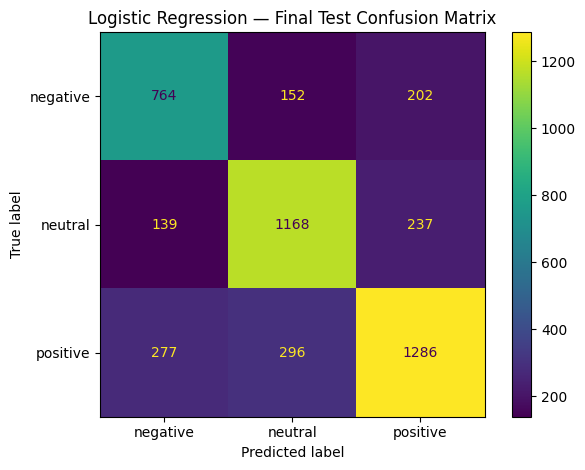

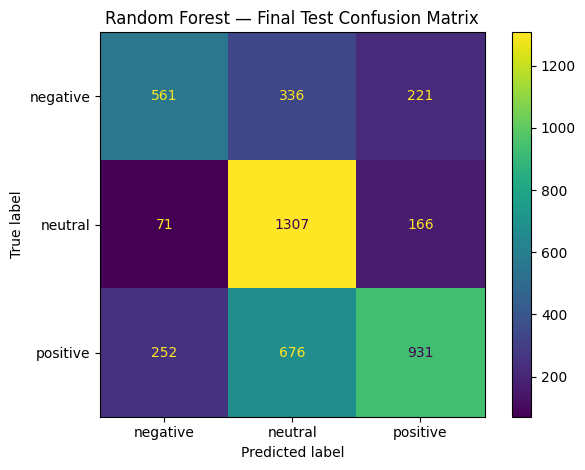

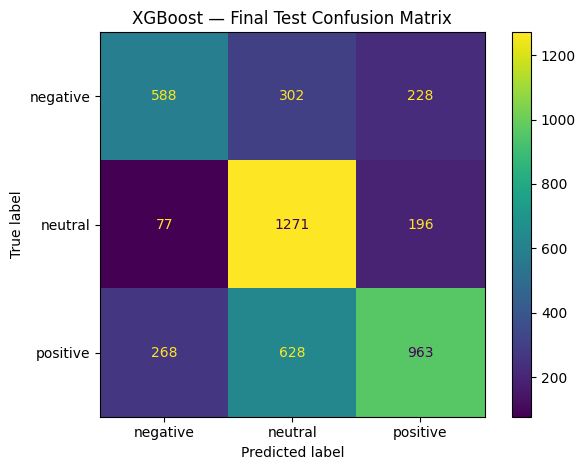

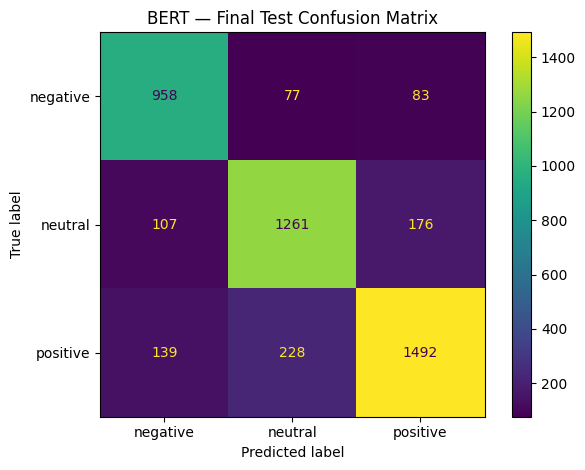

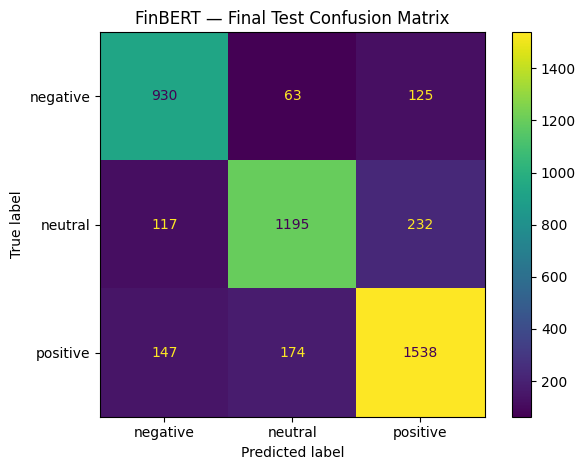

In [24]:
# 4.4 Final test confusion matrices and per-class reports.
for name in ['Logistic Regression','Random Forest','XGBoost','BERT','FinBERT']:
    pred = all_predictions[f'{name}_prediction'].to_numpy()
    cm = confusion_matrix(y_test, pred, labels=[0,1,2])
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(values_format='d')
    plt.title(f'{name} — Final Test Confusion Matrix')
    plt.tight_layout()
    safe = name.lower().replace(' ', '_')
    plt.savefig(W4 / 'figures' / f'{safe}_FINAL_test_confusion_matrix.png', dpi=200)
    plt.show()

    report = pd.DataFrame(classification_report(
        y_test, pred, labels=[0,1,2], target_names=LABELS, output_dict=True, zero_division=0
    )).T
    report.to_csv(W4 / 'tables' / f'{safe}_FINAL_test_classification_report.csv')

In [25]:
# 4.5 Source-specific test performance: directly answers the news vs social-media part of the aim.
source_rows = []
for name in ['Logistic Regression','Random Forest','XGBoost','BERT','FinBERT']:
    pred_all = all_predictions[f'{name}_prediction'].to_numpy()
    for source in sorted(test_df['source_type'].unique()):
        mask = test_df['source_type'].to_numpy() == source
        if mask.sum() < 2:
            continue
        m = calculate_metrics(y_test[mask], pred_all[mask], None)
        source_rows.append({
            'model': name,
            'source_type': source,
            'records': int(mask.sum()),
            'accuracy': m['accuracy'],
            'macro_precision': m['macro_precision'],
            'macro_recall': m['macro_recall'],
            'macro_f1': m['macro_f1'],
        })

source_results = pd.DataFrame(source_rows)
display(source_results.sort_values(['source_type','macro_f1'], ascending=[True,False]))
source_results.to_csv(W4 / 'tables' / '03_FINAL_source_specific_performance.csv', index=False)

,model,source_type,records,accuracy,macro_precision,macro_recall,macro_f1
6,BERT,news,3025,0.807934,0.787610,0.795918,0.791167
8,FinBERT,news,3025,0.792727,0.778626,0.768544,0.772457
0,Logistic Regression,news,3025,0.706116,0.685490,0.698834,0.691153
4,XGBoost,news,3025,0.598017,0.593761,0.618544,0.592438
2,Random Forest,news,3025,0.593388,0.595343,0.618207,0.588615
7,BERT,social_media,1496,0.846925,0.819748,0.810068,0.813708
9,FinBERT,social_media,1496,0.845588,0.804465,0.825238,0.813599
1,Logistic Regression,social_media,1496,0.723262,0.653391,0.654144,0.653259
5,XGBoost,social_media,1496,0.677139,0.654826,0.521259,0.550086
3,Random Forest,social_media,1496,0.671123,0.644754,0.492581,0.515421


In [26]:
# 4.6 Error-analysis evidence from the best final model.
best_model = final_results.iloc[0]['model']
pred_col = f'{best_model}_prediction'
conf_col = f'{best_model}_confidence'

error_df = pd.DataFrame({
    'row_id': test_df['row_id'],
    'source_type': test_df['source_type'],
    'text': test_df['text'],
    'true_sentiment': test_df['sentiment'],
    'predicted_sentiment': all_predictions[pred_col].map(ID2LABEL),
    'confidence': all_predictions[conf_col]
})
error_df = error_df[error_df['true_sentiment'] != error_df['predicted_sentiment']]
error_df = error_df.sort_values('confidence', ascending=False)
error_df.head(100).to_csv(W4 / 'tables' / '04_best_model_top_100_errors.csv', index=False)

print('Best final model:', best_model)
print('Number of test errors:', len(error_df))
display(error_df.head(20))

Best final model: BERT
Number of test errors: 810


,row_id,source_type,text,true_sentiment,predicted_sentiment,confidence
1089,57873,news,"Inflection AI, the start-up launched by Linked...",positive,negative,0.995079
1346,15244,news,Germany's competition regulator is looking int...,neutral,negative,0.994949
4085,59450,news,Netflix Inc (NASDAQ:NFLX ) is in the hot seat ...,positive,negative,0.994678
1214,70897,news,The company says workers violated safety polic...,neutral,negative,0.992902
1290,11470,news,Technology stocks will be taking the earnings ...,positive,negative,0.992603
4037,4501,news,NVIDIA (NASDAQ: NVDA) shares moved lower in th...,positive,negative,0.992427
2708,7967,social_media,India's October 1-November 15 sugar output dow...,neutral,negative,0.992324
21,25091,social_media,Nasdaq Composite down 0.1%; S&P 500 virtually ...,neutral,negative,0.990914
1635,20652,news,The category was marked by maturity and the re...,neutral,negative,0.989985
1352,24578,social_media,Crisis Is Rocking Latin America. Peru Is an Is...,neutral,negative,0.989732


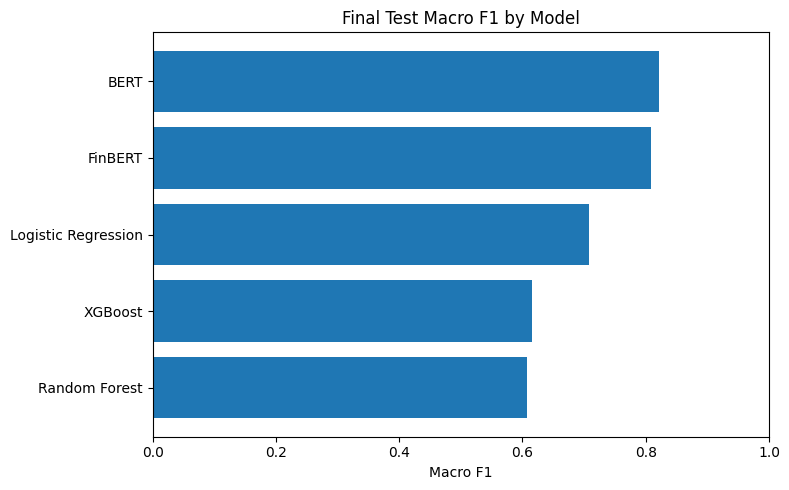

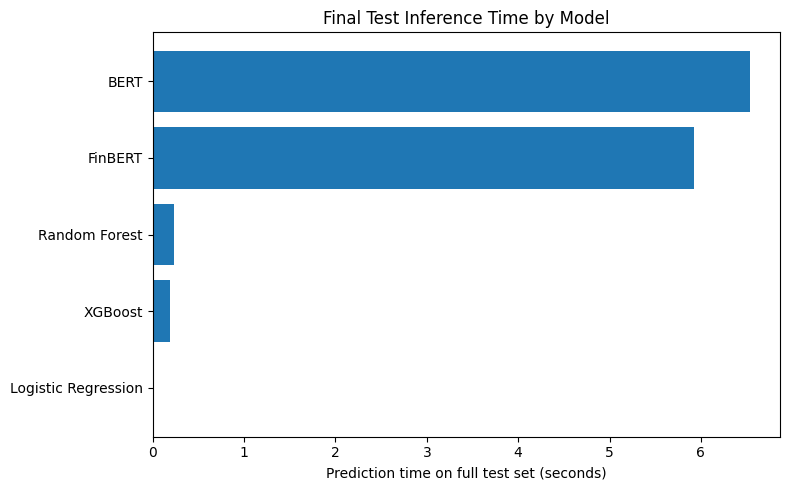

In [27]:
# 4.7 Final performance figure for the dissertation.
plot_df = final_results.sort_values('macro_f1')
plt.figure(figsize=(8,5))
plt.barh(plot_df['model'], plot_df['macro_f1'])
plt.xlabel('Macro F1')
plt.title('Final Test Macro F1 by Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(W4 / 'figures' / '01_FINAL_macro_f1_model_comparison.png', dpi=220)
plt.show()

plot_df2 = final_results.sort_values('prediction_seconds')
plt.figure(figsize=(8,5))
plt.barh(plot_df2['model'], plot_df2['prediction_seconds'])
plt.xlabel('Prediction time on full test set (seconds)')
plt.title('Final Test Inference Time by Model')
plt.tight_layout()
plt.savefig(W4 / 'figures' / '02_FINAL_inference_time_comparison.png', dpi=220)
plt.show()